In [ ]:
import pandas as pd
df = pd.read_csv("/content/Superstore dataset.csv", encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
today = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x:(today-x.max()).days,
    'Order ID':'count',
    'Sales':'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,184,11,5563.560
AA-10375,19,15,1056.390
AA-10480,259,12,1790.512
AA-10645,55,18,5086.935
AB-10015,415,6,886.156


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(rfm_scaled)

    inertia.append(km.inertia_)

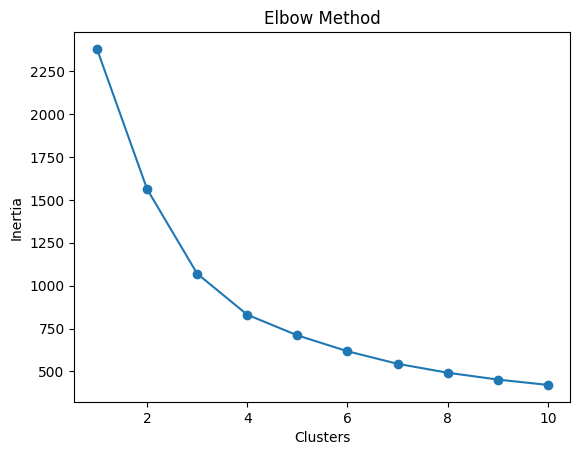

In [ ]:
import matplotlib.pyplot as plt

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

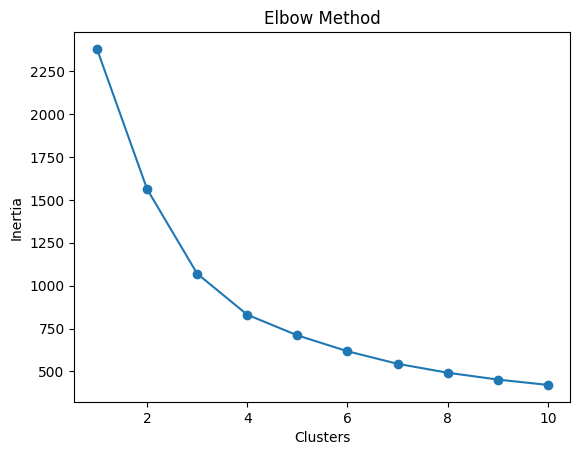

In [ ]:
import matplotlib.pyplot as plt

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
3,348
0,277
1,105
2,63


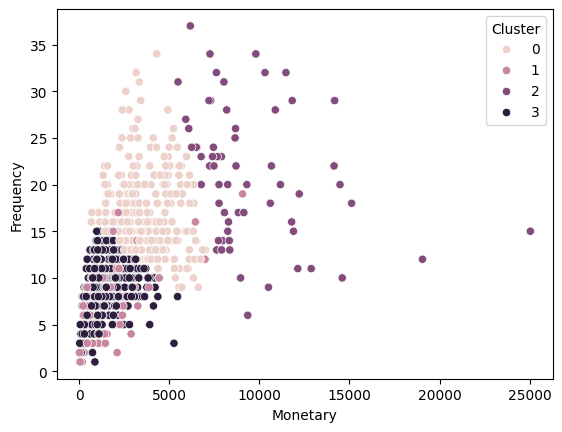

In [ ]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x='Monetary',
    y='Frequency',
    hue='Cluster'
)

plt.show()

In [ ]:
import joblib

joblib.dump(
    kmeans,
    "customer_cluster.pkl"
)

print("Saved Successfully")

Saved Successfully


In [ ]:
from google.colab import files

files.download("customer_cluster.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>